In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from src.preprocessing import fit_preprocessing, transform_preprocessor
from src.models import compare_models, predict_and_score

from src.utils import roc_graph

## 코드 테스트

In [2]:
# 데이터 호출
df = pd.read_csv('./data/train.csv')

In [3]:
# X/y split
X = df.drop('churned', axis=1)
y = df['churned']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tr/val split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [4]:
# 데이터 전처리 함수 호출
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
X_test_prep = transform_preprocessor(X_test, encoders, scaler)

In [5]:
# 약 40분 소요
models = compare_models(X_tr, X_tr_prep, X_val, X_val_prep, y_tr, y_val)

In [6]:
# 약 18분 소요
train_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        train_scores[model.__class__.__name__] = predict_and_score(model, X_tr, y_tr)
        continue

    train_scores[model.__class__.__name__] = predict_and_score(model, X_tr_prep, y_tr)


LogisticRegression Results
Accuracy : 0.6844
F1 Score : 0.6949
ROC AUC  : 0.7561

SVC Results
Accuracy : 0.8219
F1 Score : 0.8276
ROC AUC  : 0.9048

CatBoostClassifier Results
Accuracy : 0.8680
F1 Score : 0.8698
ROC AUC  : 0.9511

XGBClassifier Results
Accuracy : 0.8819
F1 Score : 0.8838
ROC AUC  : 0.9578

LGBMClassifier Results
Accuracy : 0.8728
F1 Score : 0.8755
ROC AUC  : 0.9534

RandomForestClassifier Results
Accuracy : 0.8124
F1 Score : 0.8163
ROC AUC  : 0.9006


In [14]:
# 약 1분 소요
val_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        val_scores[model.__class__.__name__] = predict_and_score(model, X_val, y_val)
        continue

    val_scores[model.__class__.__name__] = predict_and_score(model, X_val_prep, y_val)


LogisticRegression Results
Accuracy : 0.6733
F1 Score : 0.6870
ROC AUC  : 0.7465

SVC Results
Accuracy : 0.7818
F1 Score : 0.7888
ROC AUC  : 0.8691

CatBoostClassifier Results
Accuracy : 0.8402
F1 Score : 0.8423
ROC AUC  : 0.9369

XGBClassifier Results
Accuracy : 0.8404
F1 Score : 0.8436
ROC AUC  : 0.9373

LGBMClassifier Results
Accuracy : 0.8420
F1 Score : 0.8457
ROC AUC  : 0.9376

RandomForestClassifier Results
Accuracy : 0.8065
F1 Score : 0.8105
ROC AUC  : 0.8943


In [7]:
# 약 4분 소요
test_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        test_scores[model.__class__.__name__] = predict_and_score(model, X_test, y_test)
        continue

    test_scores[model.__class__.__name__] = predict_and_score(model, X_test_prep, y_test)


LogisticRegression Results
Accuracy : 0.6802
F1 Score : 0.6911
ROC AUC  : 0.7523

SVC Results
Accuracy : 0.7887
F1 Score : 0.7960
ROC AUC  : 0.8746

CatBoostClassifier Results
Accuracy : 0.8486
F1 Score : 0.8507
ROC AUC  : 0.9422

XGBClassifier Results
Accuracy : 0.8490
F1 Score : 0.8516
ROC AUC  : 0.9421

LGBMClassifier Results
Accuracy : 0.8493
F1 Score : 0.8522
ROC AUC  : 0.9422

RandomForestClassifier Results
Accuracy : 0.8136
F1 Score : 0.8178
ROC AUC  : 0.8996


In [8]:
train_scores_df = pd.DataFrame(train_scores).T[['accuracy','f1','roc_auc']]
train_scores_df

,accuracy,f1,roc_auc
LogisticRegression,0.684367,0.694873,0.756054
SVC,0.821878,0.827637,0.904759
CatBoostClassifier,0.868044,0.869769,0.951053
XGBClassifier,0.8819,0.883797,0.957765
LGBMClassifier,0.872833,0.875453,0.953404
RandomForestClassifier,0.8124,0.816343,0.900606


In [16]:
val_scores_df = pd.DataFrame(val_scores).T[['accuracy','f1','roc_auc']]
val_scores_df

,accuracy,f1,roc_auc
LogisticRegression,0.6733,0.686979,0.746506
SVC,0.7818,0.788771,0.86907
CatBoostClassifier,0.8402,0.842344,0.936864
XGBClassifier,0.8404,0.84356,0.937305
LGBMClassifier,0.842,0.845673,0.937611
RandomForestClassifier,0.8065,0.810536,0.894321


In [9]:
test_scores_df = pd.DataFrame(test_scores).T[['accuracy','f1','roc_auc']]
test_scores_df

,accuracy,f1,roc_auc
LogisticRegression,0.68016,0.691059,0.752264
SVC,0.78868,0.795952,0.874641
CatBoostClassifier,0.8486,0.85072,0.942222
XGBClassifier,0.849,0.851606,0.942058
LGBMClassifier,0.84932,0.852153,0.942186
RandomForestClassifier,0.81364,0.817787,0.899589


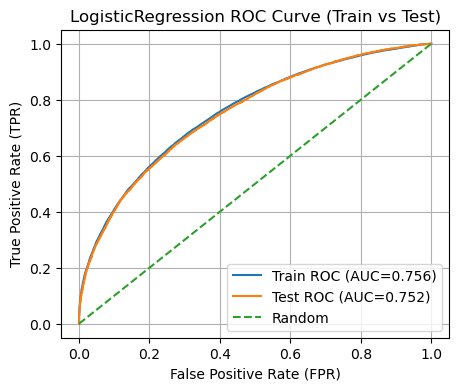

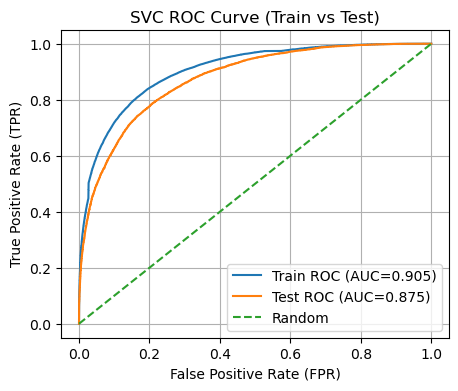

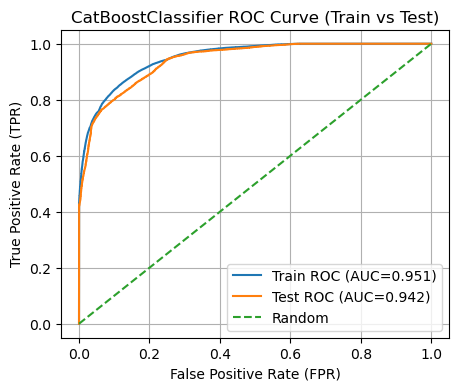

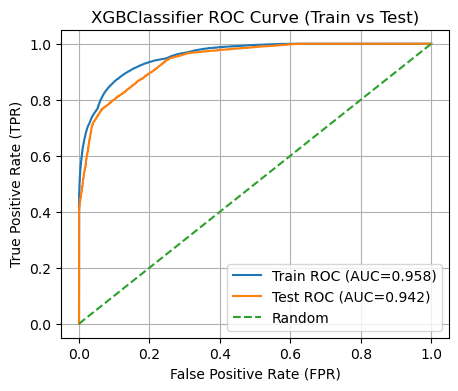

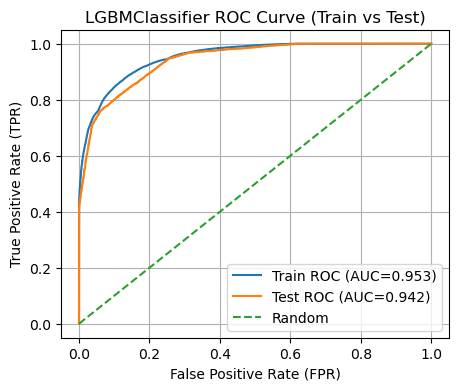

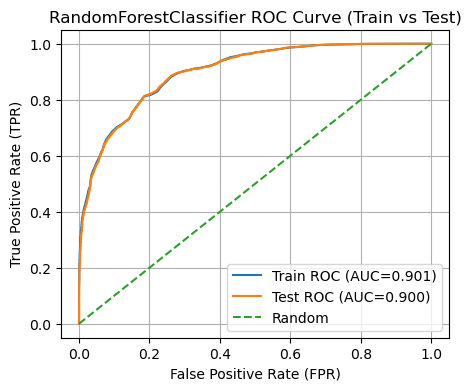

In [10]:
for model in models:

    name = model.__class__.__name__
    y_train_pred = train_scores[name]['y_proba']
    y_test_pred = test_scores[name]['y_proba']

    roc_graph(name, y_tr, y_train_pred, y_test, y_test_pred)